In [12]:
# --- IMPORTS ---
import pandas as pd              # Práca s tabuľkami (DataFrame)
import numpy as np               # Matematika a polia
import matplotlib.pyplot as plt  # Základné grafy
import seaborn as sns            # Krajšie štatistické grafy
import scipy.stats as stats      # Štatistické testy (T-testy, ANOVA...)
import statsmodels.api as sm     # Pokročilá štatistika (Regresia)
import statsmodels.formula.api as smf # R-style formuly pre regresiu

print("✅ Libraries successfully loaded!")

✅ Libraries successfully loaded!


In [21]:
try:
    df = pd.read_csv('bmw_global_sales_dataset.csv', sep=',')
    print("✅ Data successfully loaded.")
except FileNotFoundError:
    print("ERROR: File not found.")

df.head()

✅ Data successfully loaded.


,year,month,country,model,segment,engine_type,price_usd,marketing_spend_usd,dealership_count,fuel_price_usd,gdp_growth_percent,interest_rate_percent,competition_index,units_sold
0,2021,1,Australia,X1,SUV,Petrol,82234,315372,96,0.97,6.29,1.2,8,324
1,2018,8,Australia,i4,Sedan,Electric,82291,447798,234,0.97,6.29,1.2,7,556
2,2022,12,USA,5 Series,Electric,Hybrid,40594,259755,25,0.97,6.29,1.2,7,152
3,2019,11,Australia,i7,SUV,Electric,42371,323541,319,0.97,6.29,1.2,5,730
4,2021,12,Brazil,X5,SUV,Diesel,82315,482015,367,0.97,6.29,1.2,2,1156


In [45]:
# 2. Vyčistenie názvov stĺpcov
df.columns = df.columns.str.strip()

# 3. Funkcia na bezpečný prevod na číslo
def clean_number(value):
    if pd.isna(value): return None
    # Ak je to string a obsahuje čiarku, odstránime ju
    val_str = str(value).replace(',', '')
    return pd.to_numeric(val_str, errors='coerce')

# Aplikujeme na tvoje premenné
cols = ['price_usd', 'marketing_spend_usd', 'dealership_count']
target = 'units_sold'

for col in cols + [target]:
    df[col] = df[col].apply(clean_number)

# 4. Diagnostika - koľko dát máme v ktorom stĺpci?
print("Počet platných čísiel v jednotlivých stĺpcoch:")
print(df[cols + [target]].count())

# 5. Odstránenie NaN a spustenie regresie
df_clean = df.dropna(subset=cols + [target])
print(f"\nFinálny počet riadkov pre model: {len(df_clean)}")

if len(df_clean) > 0:
    X = df_clean[cols]
    y = df_clean[target]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()  # Ordinary least square = fith the best linear line
    print(model.summary())
else:
    print("⚠️ Model stále nemá dáta. Skúsme namiesto 'o3_median' použiť 'temperature_median'.")

Počet platných čísiel v jednotlivých stĺpcoch:
price_usd              1000
marketing_spend_usd    1000
dealership_count       1000
units_sold             1000
dtype: int64

Finálny počet riadkov pre model: 1000
                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.759
Method:                 Least Squares   F-statistic:                     1048.
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.39e-307
Time:                        11:26:40   Log-Likelihood:                -6279.4
No. Observations:                1000   AIC:                         1.257e+04
Df Residuals:                     996   BIC:                         1.259e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         

In [50]:
# tss = rss + mss
tss = model.centered_tss
mss = model.ess
rss = model.ssr

print(f"MSS (Vysvetlené modelom): {mss}")
print(f"RSS (Chyba modelu): {rss}")
print(f"TSS (Celková variabilita): {tss}")

MSS (Vysvetlené modelom): 53119890.468449995
RSS (Chyba modelu): 16162204.667550012
TSS (Celková variabilita): 69282095.136


Vidim, ze R2 je 0.760 pri cisto numericky kategoriach. Teraz skusim pridat aj nejake kategoricke cez Target Encoding.

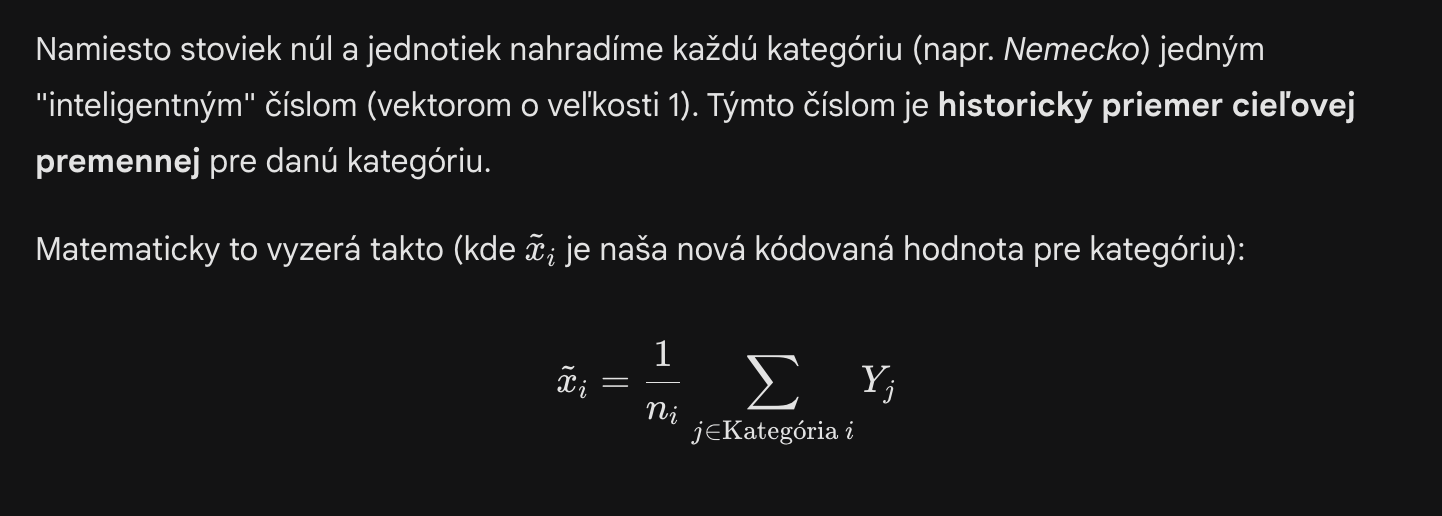

In [49]:
# 2. Vytvoríme si kópiu dát, aby sme neprepísali originál
df_smart = df.copy()

# 3. Zoznam kategórií, pre ktoré chceme urobiť Target Encoding
# (Mesiace necháme ako čísla, Pandas si ich pri groupby automaticky zoskupí)
categorical_cols = ['country', 'model', 'competition_index']

# 4. Implementácia Target Encodingu
for col in categorical_cols:
    # Vypočítame priemerné predaje (units_sold) pre každú unikátnu hodnotu v stĺpci
    mean_encoded = df.groupby(col)['units_sold'].mean()
    
    # Namapujeme tieto "inteligentné váhy" späť do nášho datasetu
    # Vzniknú nám nové stĺpce, napr. 'country_encoded'
    df_smart[f'{col}_encoded'] = df_smart[col].map(mean_encoded)

# 5. Príprava na regresiu - teraz použijeme len naše inteligentné vektory
# Všimni si, že máme len 5 nových stĺpcov, nie 50 ako pri OHE!
X_cols = [f'{col}_encoded' for col in categorical_cols] + cols
X = df_smart[X_cols]
y = df_smart['units_sold']

# 6. Model
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:             units_sold   R-squared:                       0.767
Model:                            OLS   Adj. R-squared:                  0.765
Method:                 Least Squares   F-statistic:                     543.9
Date:                Thu, 26 Feb 2026   Prob (F-statistic):          1.04e-309
Time:                        11:27:43   Log-Likelihood:                -6264.2
No. Observations:                1000   AIC:                         1.254e+04
Df Residuals:                     993   BIC:                         1.258e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

* competition_index_encoded     0.5521      0.166      3.324      0.001       **0.226** - sanca 22.6, ze je to nahoda, ako to vplyva na predaj a preto R-squared:0.767 a Adj. R-squared:0.765 je rozdiel
* Vzorec pre marketing_spend_usd:
* $$Y = 0.0001 \times \text{marketing\_spend\_usd}$$
* Aký rozpočet (koľko dolárov) musí automobilka vraziť do marketingu, aby na základe tohto modelu dokázala predať presne 1 auto navyše?
(Tip: Vyrieš rovnicu, kde Y = 1)
* 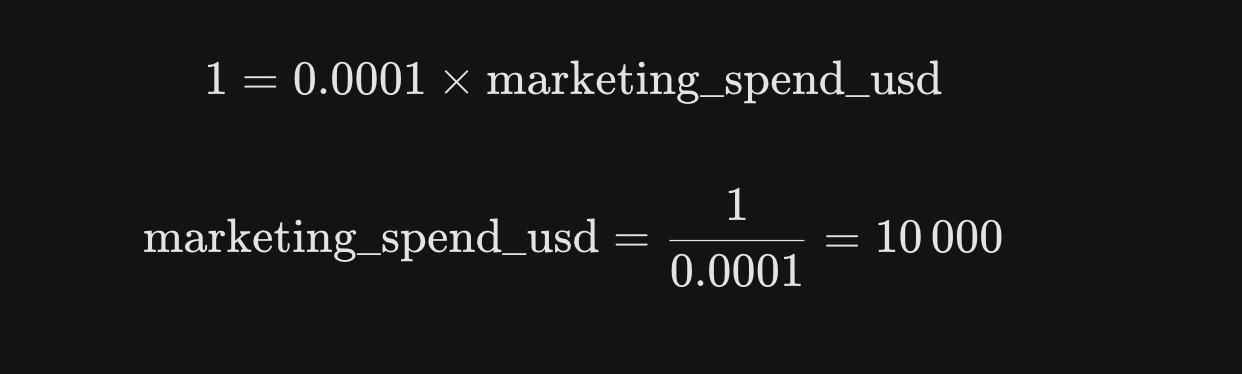
* 
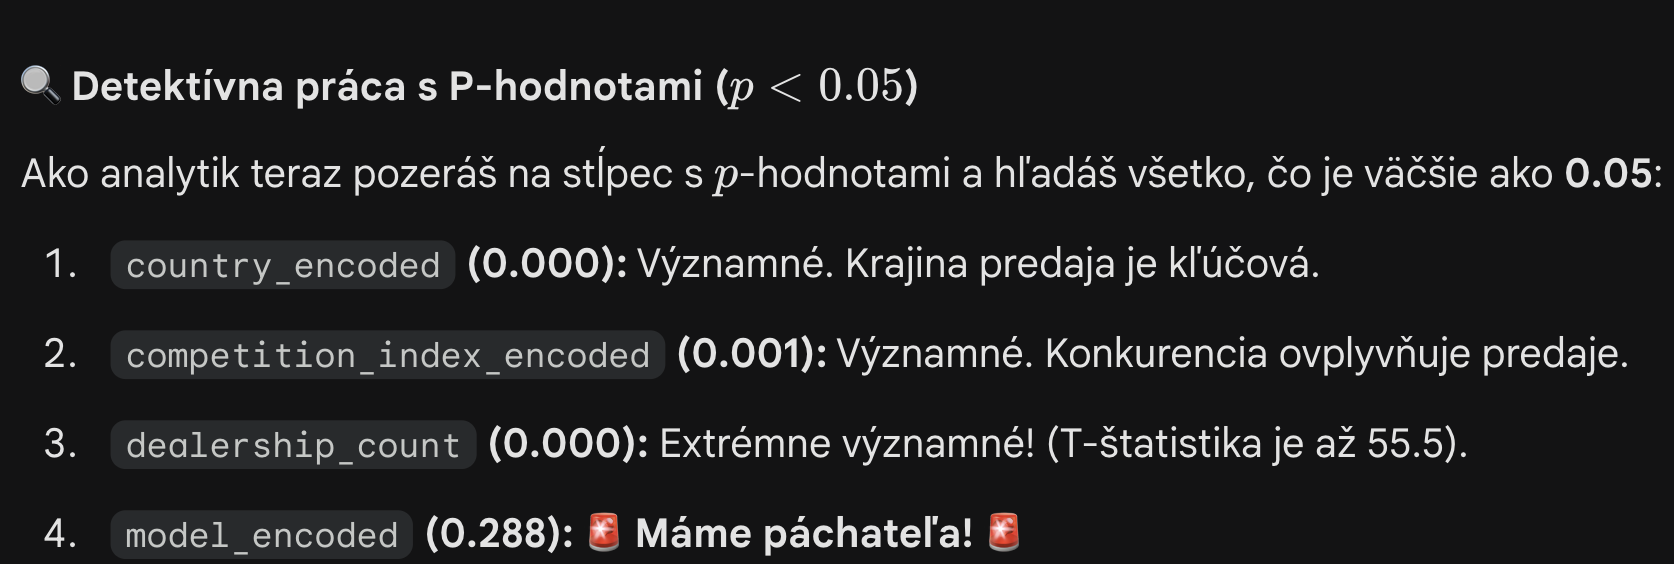
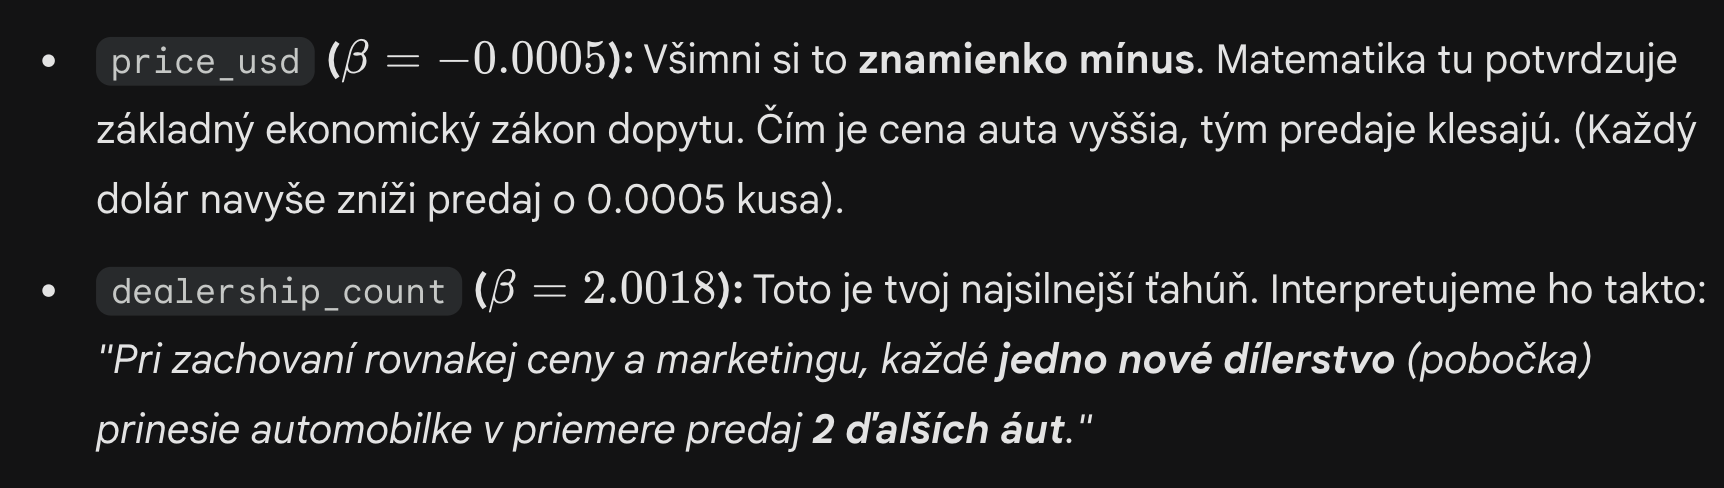

### Predpoklady LG
Lineárna regresia funguje len vtedy, ak platia jej základné predpoklady. Ak sú porušené, náš model by systematicky klamal (napríklad by preceňoval lacné autá a podceňoval drahé).
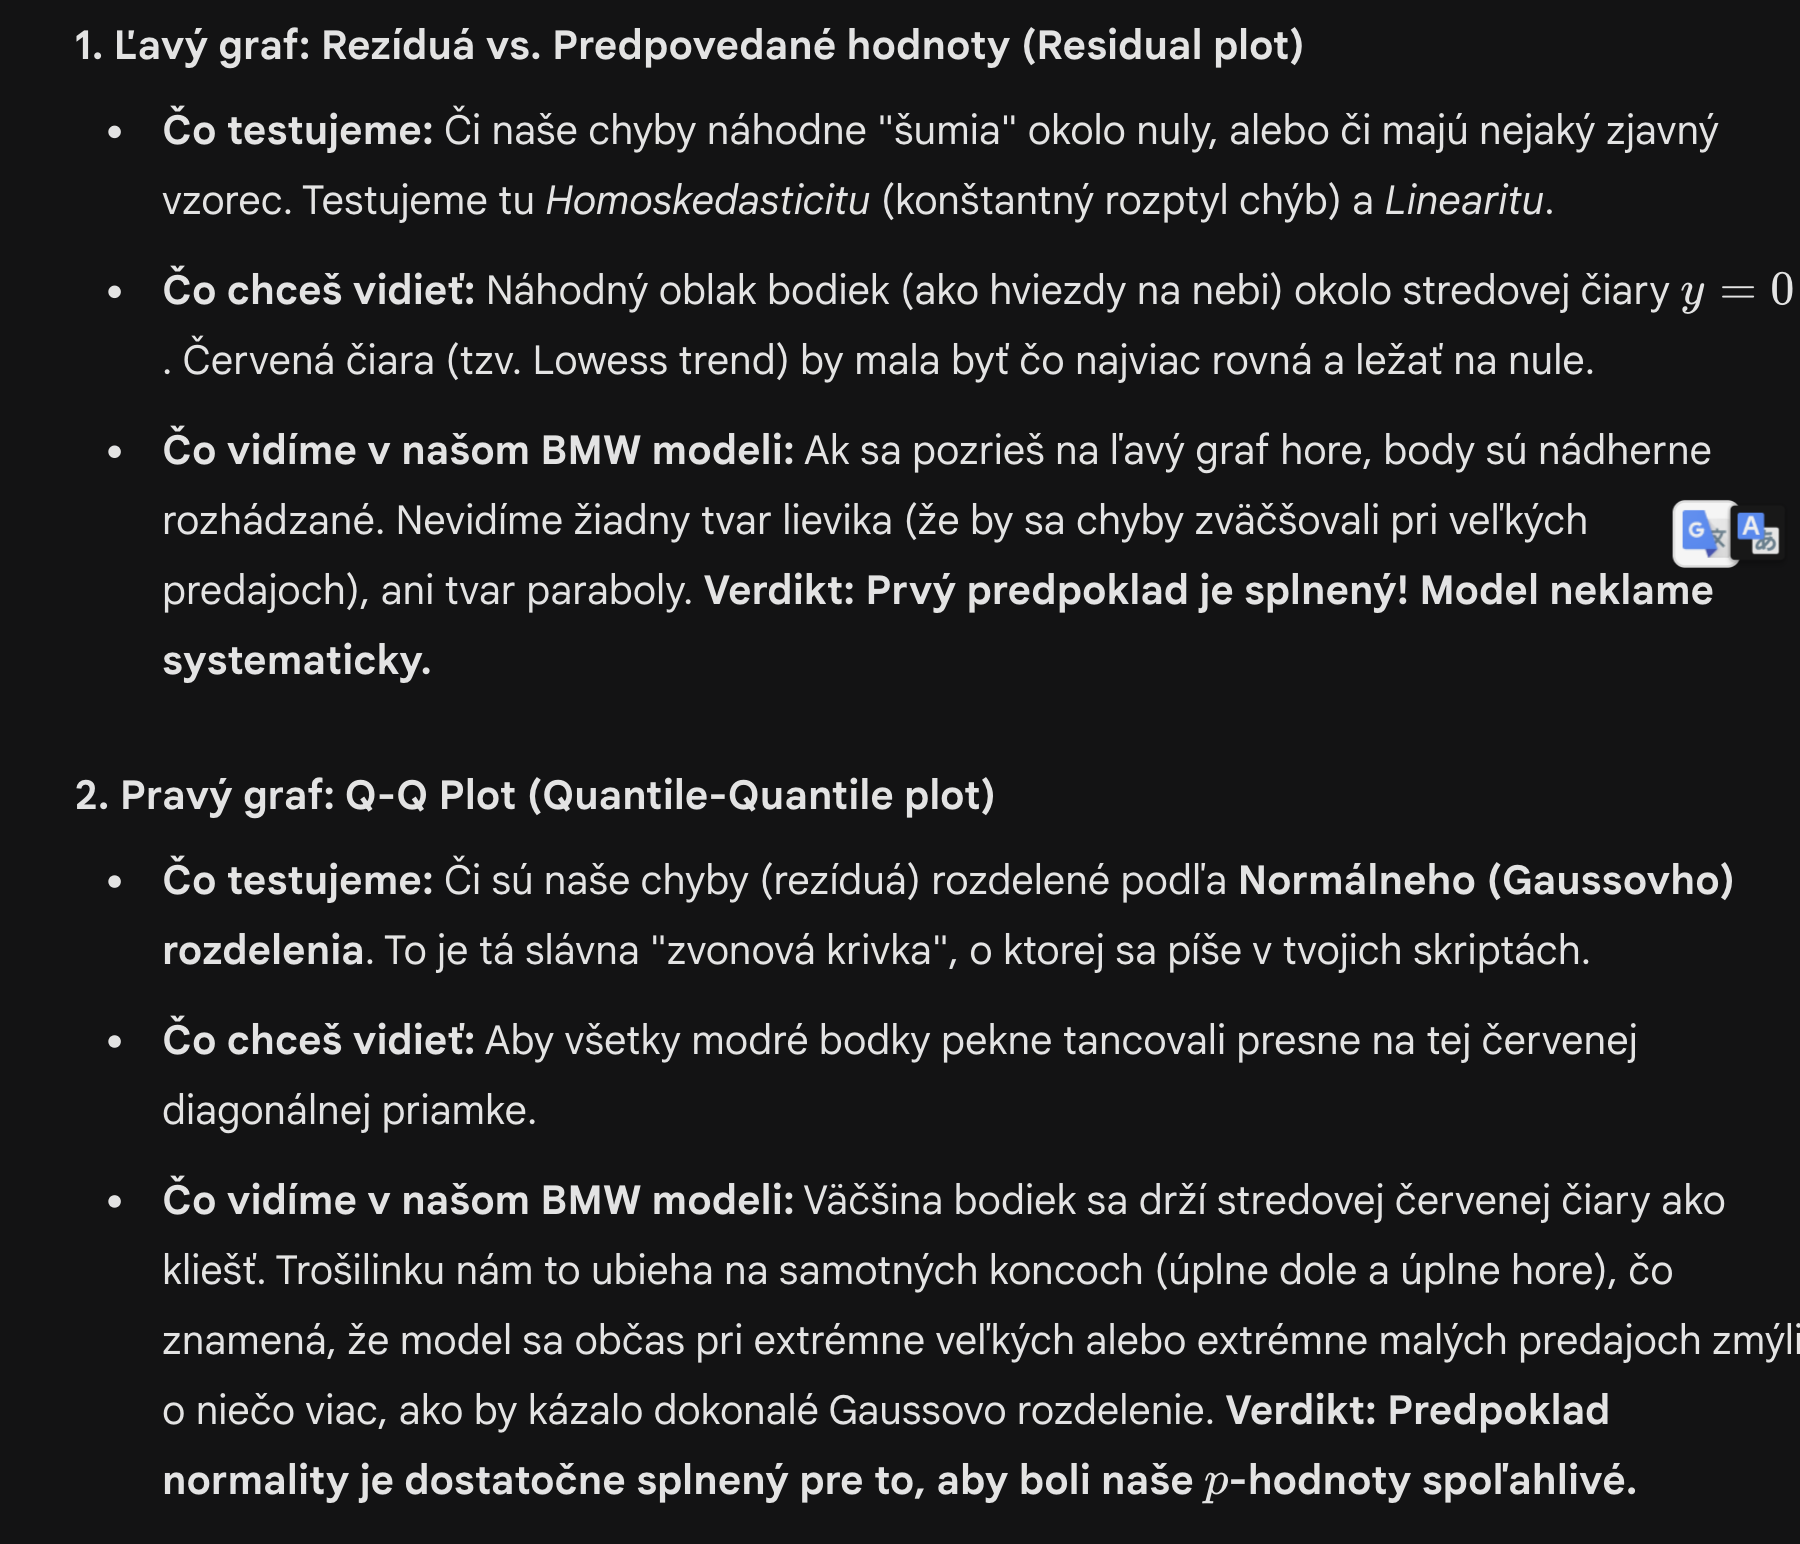

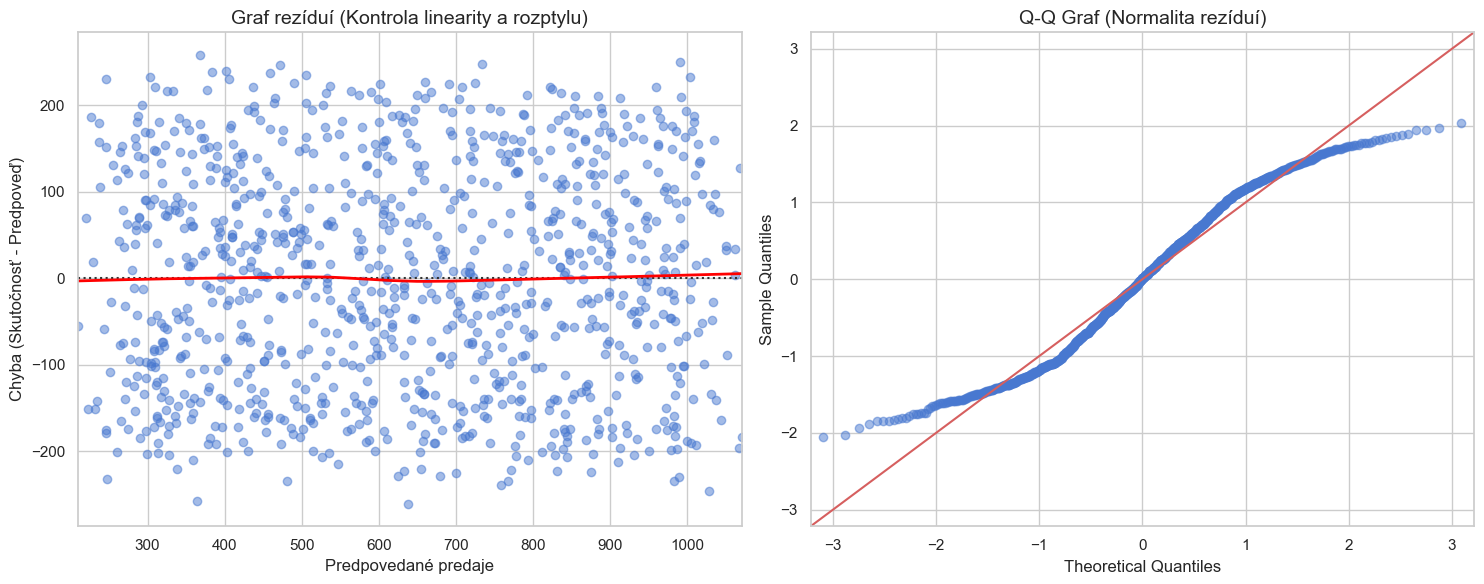

In [51]:
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# (Predpokladáme, že tu máme už natrénovaný model z predchádzajúceho kroku)
# y = ...
# X = ...
# model = sm.OLS(y, X).fit()

# Nastavenie veľkosti obrázkov
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Graf: Rezíduá vs. Predpovedané hodnoty (Residuals vs Fitted)
sns.residplot(x=model.fittedvalues, y=model.resid, lowess=True, 
              scatter_kws={'alpha': 0.5}, line_kws={'color': 'red', 'lw': 2}, ax=axes[0])
axes[0].set_title('Graf rezíduí (Kontrola linearity a rozptylu)', fontsize=14)
axes[0].set_xlabel('Predpovedané predaje', fontsize=12)
axes[0].set_ylabel('Chyba (Skutočnosť - Predpoveď)', fontsize=12)

# 2. Graf: Q-Q graf (Kontrola normality)
sm.qqplot(model.resid, line='45', fit=True, ax=axes[1], alpha=0.5)
axes[1].set_title('Q-Q Graf (Normalita rezíduí)', fontsize=14)

plt.tight_layout()
plt.show()

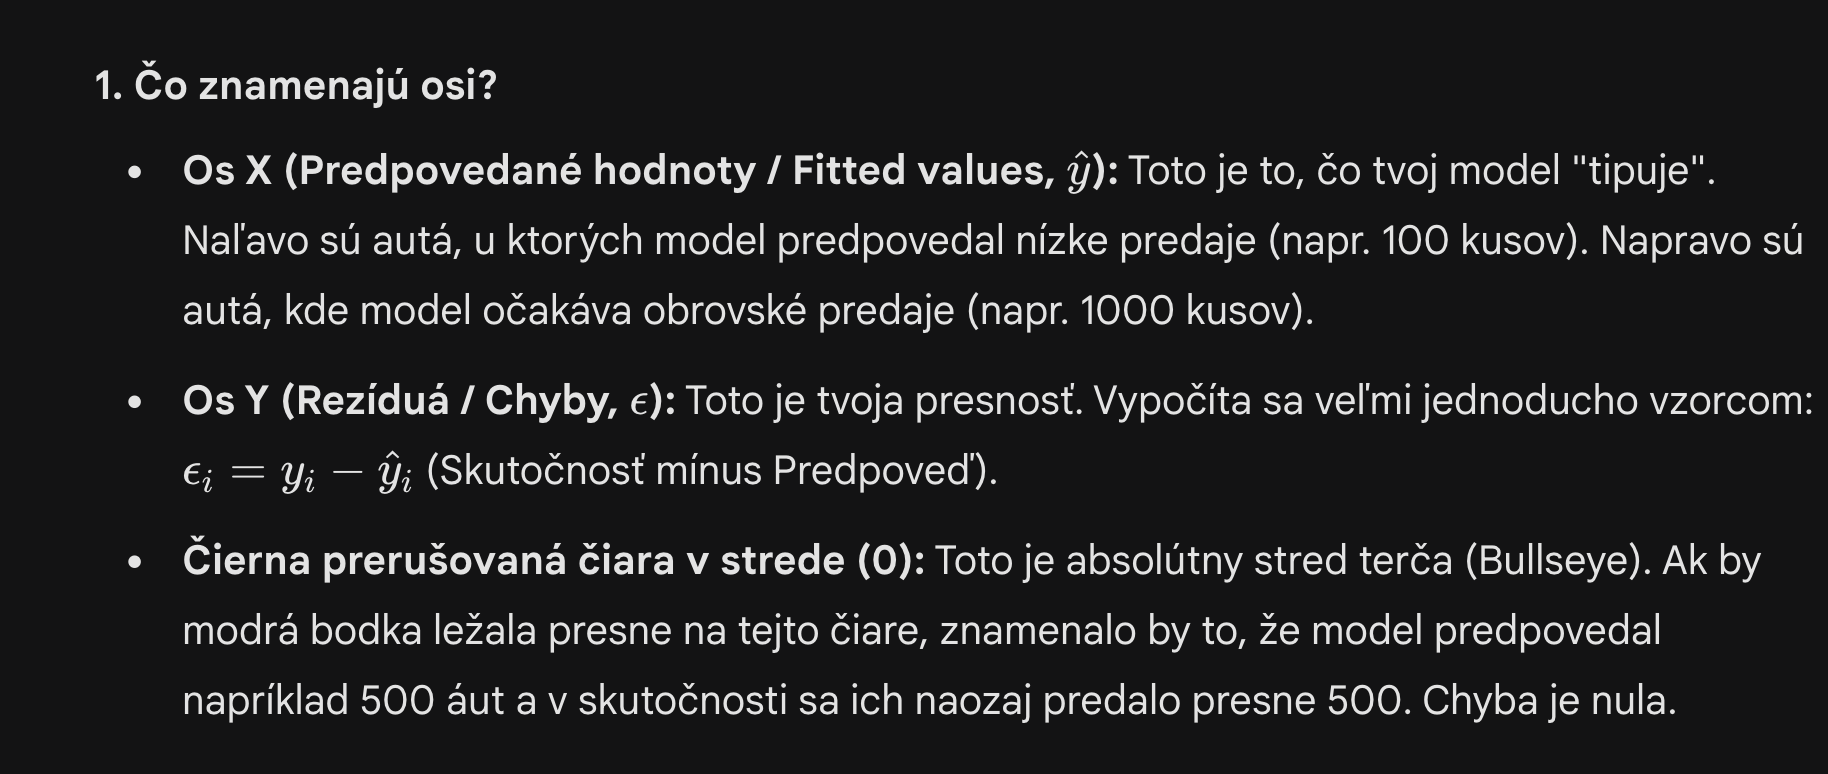
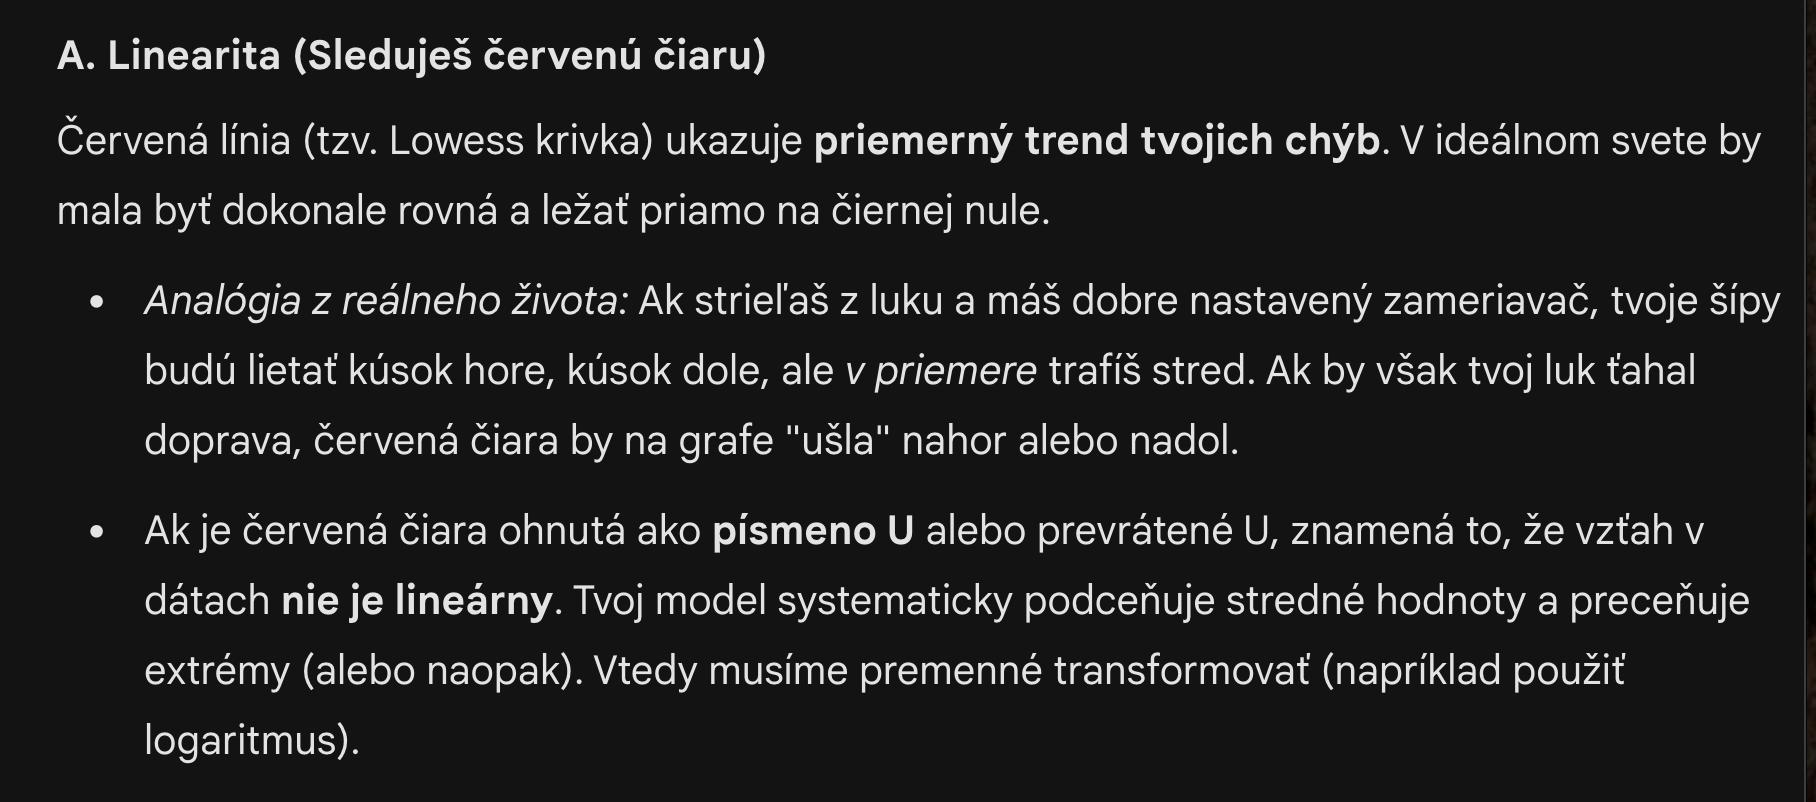
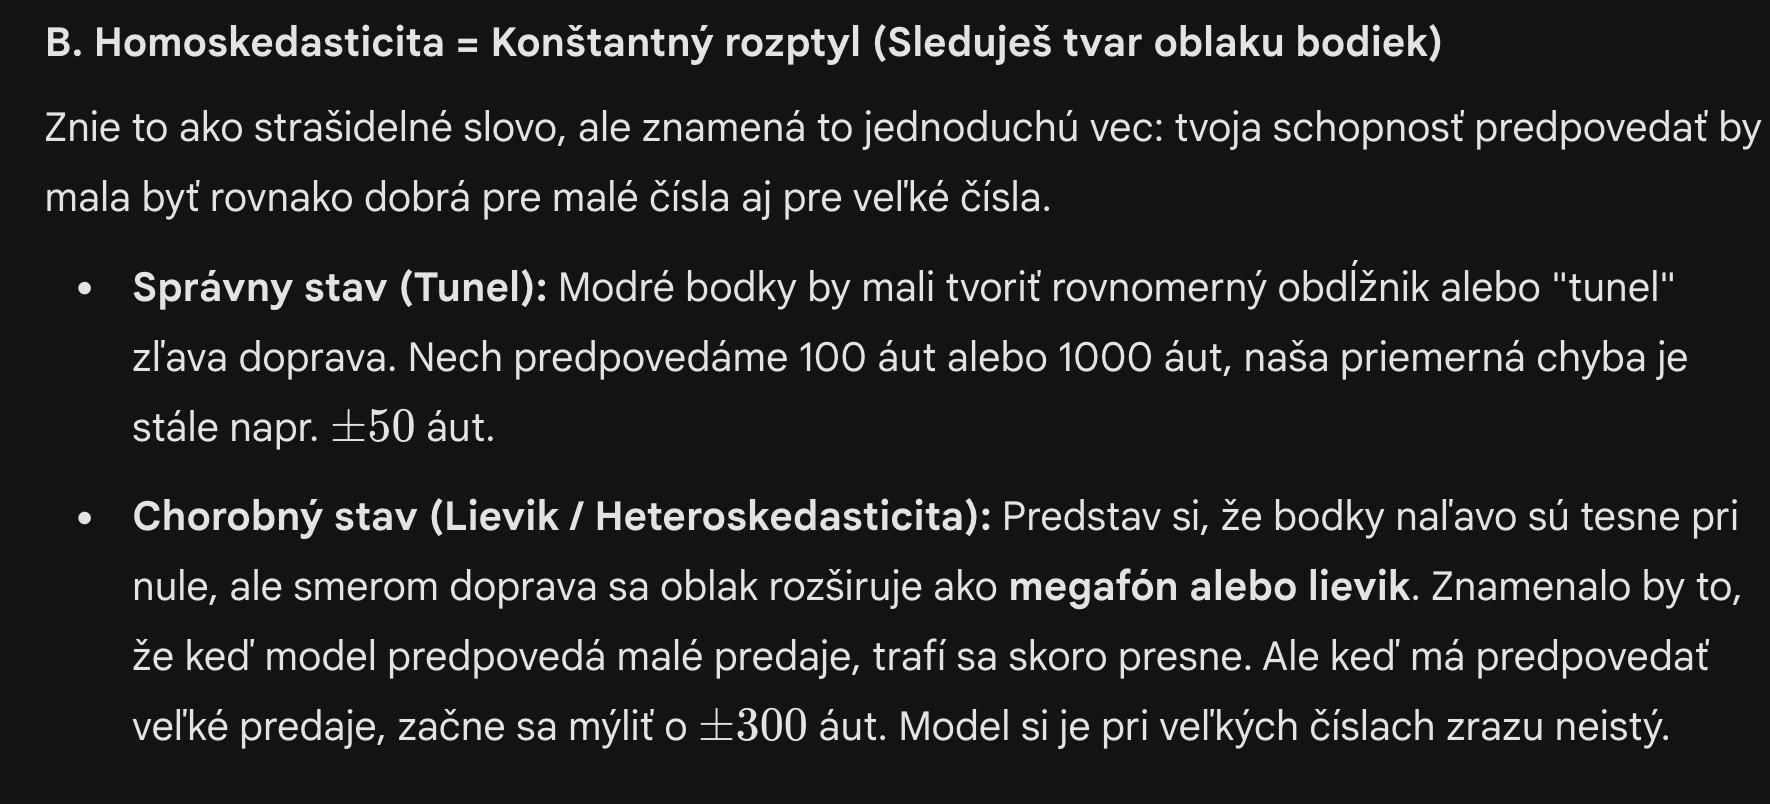